# Tire Pressure vs Lateral Force

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as stats

df = pd.read_csv("B2356raw9.dat", sep='\s+', header=1, skiprows=[2])
df = df.apply(pd.to_numeric, errors='coerce')
df.head()

,ET,V,N,SA,IA,RL,RE,P,FX,FY,...,MX,MZ,NFX,NFY,RST,TSTI,TSTC,TSTO,AmbTmp,SR
0,0.00,0.02,0.01,0.004,-0.012,19.32,697.32,82.41,3.37,-56.08,...,-2.65,1.50,-0.0030,0.0502,32.39,37.48,39.43,41.51,26.39,-0.9723
1,0.01,0.03,0.01,-0.004,-0.016,19.32,968.73,82.46,2.40,-54.67,...,-2.52,1.13,-0.0021,0.0489,32.40,37.46,39.45,41.48,26.37,-0.9801
2,0.02,0.03,0.01,-0.004,-0.003,19.32,968.73,82.51,1.86,-54.73,...,-2.51,0.90,-0.0017,0.0490,32.40,37.43,39.41,41.50,26.38,-0.9801
3,0.03,0.01,-0.06,-0.007,0.001,19.31,-65.53,82.41,1.85,-53.36,...,-2.15,0.92,-0.0017,0.0478,32.39,37.44,39.40,41.50,26.39,-1.2948
4,0.04,0.04,0.01,0.012,-0.002,19.31,1240.13,82.26,0.04,-51.96,...,-2.07,0.50,-0.0000,0.0466,32.39,37.41,39.40,41.46,26.38,-0.9844


In [2]:
# Given parameters: normal load, slip angle
targetFZ = -1112
toleranceFZ = 50
targetSA = 6.0
toleranceSA = 0.2

In [3]:
# Filter dataframe for rows where load and slip angle match targets
points = df[
    (df['FZ'].between(targetFZ - toleranceFZ, targetFZ + toleranceFZ)) &
    (df['SA'].between(targetSA - toleranceSA, targetSA + toleranceSA))
]

# Group by the target pressure and average the lateral force
points['P_target'] = (points['P'] * 0.145038).round(0)
summary = points.groupby('P_target')['FY'].mean().reset_index()

/tmp/ipykernel_216/515135301.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  points['P_target'] = (points['P'] * 0.145038).round(0)


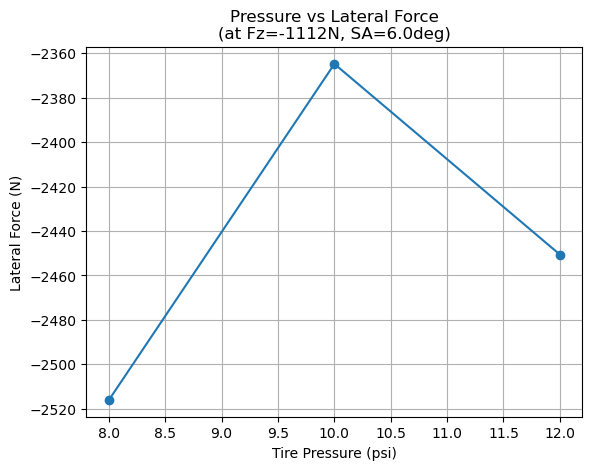

In [4]:
# Plot
plt.plot(summary['P_target'], summary['FY'], marker='o', linestyle='-')
plt.title(f'Pressure vs Lateral Force\n(at Fz={targetFZ}N, SA={targetSA}deg)')
plt.xlabel('Tire Pressure (psi)')
plt.ylabel('Lateral Force (N)')
plt.grid(True)
plt.show()

# Investigation of Energy Transfer Into Tires
## Formulas:
Power dissipation formula
P_d = -(FX * V + FY * V * sin(SA) + M_z * omega_z)
- Longitudinal slip power: FX * Sliding Velocity
- Lateral slip power: FY * V * sin(SA)
- Steering power: M_z * omega_z
- M_z is the aligning torque
- omega_z is the angular velocity ~ delta SA / delta time

In [5]:
# Changing units
df['V_ms'] = df['V']/3.6 # changes V from kph to mps
df['SA_rad'] = np.radians(df['SA']) # changes SA from deg to rad

# Calculating parts for the power dissipation formula
# lateral slip power:
df['Power_Lat'] = df['FY']*df['V_ms']*np.sin(df['SA_rad'])
# average temperature:
df['Temp_avg'] = (df['TSTI'] + df['TSTC'] + df['TSTO']) / 3

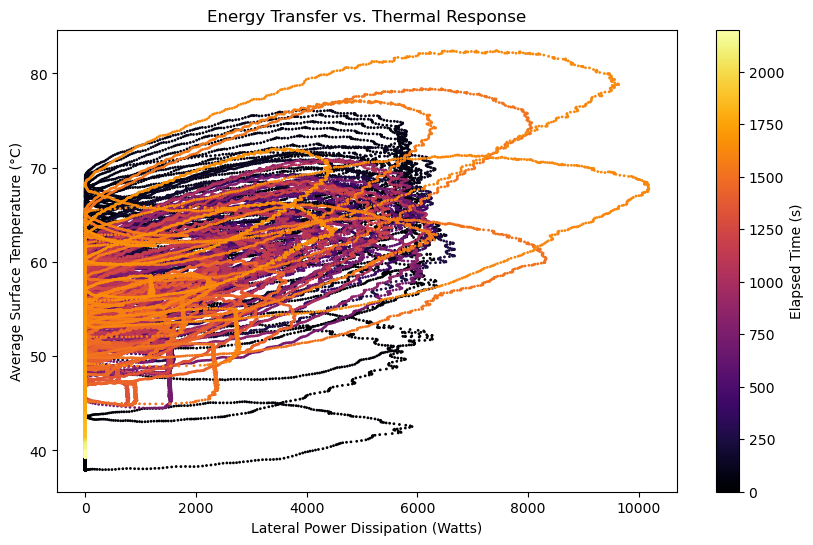

In [6]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Power_Lat'].abs(), df['Temp_avg'], c=df['ET'], cmap='inferno', s=1)
plt.xlabel('Lateral Power Dissipation (Watts)')
plt.ylabel('Average Surface Temperature (°C)')
plt.title('Energy Transfer vs. Thermal Response')
plt.colorbar(label='Elapsed Time (s)')
plt.show()

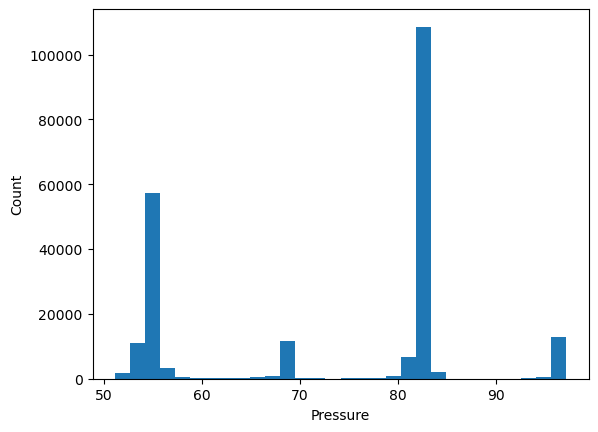

In [7]:
plt.hist(df["P"], bins=30)
plt.xlabel("Pressure")
plt.ylabel("Count")
plt.show()

In [8]:
bins = [7, 9, 11, 13, 15]
labels = ["8 psi","10 psi", "12 psi", "14 psi"]
df_clean = df[(df["FZ"] <- 200) & (abs(df["SA"]) < 15) & (abs(df["SR"]))]
df_clean["P_psi"] = df_clean["P"]/6.89476
df_clean["P_psi"].describe()

/tmp/ipykernel_216/3039168252.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["P_psi"] = df_clean["P"]/6.89476


count    219216.000000
mean         10.607959
std           2.030183
min           7.411425
25%           7.998828
50%          11.938052
75%          11.996067
max          14.094762
Name: P_psi, dtype: float64

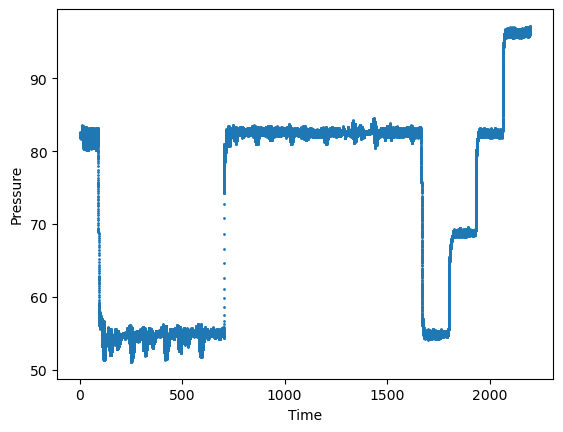

In [9]:
plt.scatter(df_clean["ET"], df_clean["P"], s=1)
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.show()

In [10]:
df_clean["P_bin"] = pd.cut(df_clean["P_psi"], bins=bins, labels=labels)
df_clean["P_bin"].value_counts()

/tmp/ipykernel_216/1355784179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["P_bin"] = pd.cut(df_clean["P_psi"], bins=bins, labels=labels)


P_bin
12 psi    118203
8 psi      74093
10 psi     13492
14 psi     13428
Name: count, dtype: int64

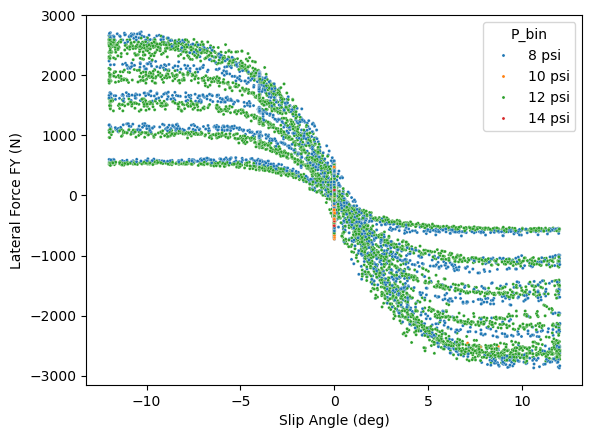

In [11]:
sns.scatterplot(
    data=df_clean.sample(20000),
    x="SA",
    y="FY",
    hue="P_bin",
    s=5
)
plt.xlabel("Slip Angle (deg)")
plt.ylabel("Lateral Force FY (N)")
plt.show()

In [12]:
peak_fy = df_clean.groupby("P_bin")["FY"].max()
scale = peak_fy / peak_fy.loc["12 psi"]
print(scale)

P_bin
8 psi     1.027148
10 psi    0.204115
12 psi    1.000000
14 psi    0.177936
Name: FY, dtype: float64


/tmp/ipykernel_216/3659239555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_fy = df_clean.groupby("P_bin")["FY"].max()


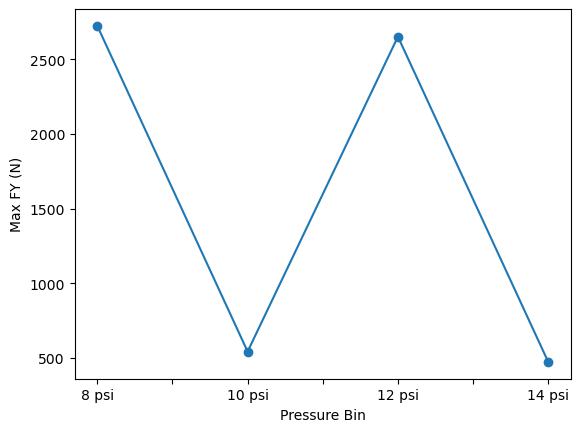

In [13]:
peak_fy.plot(marker='o')
plt.ylabel("Max FY (N)")
plt.xlabel("Pressure Bin")
plt.show()

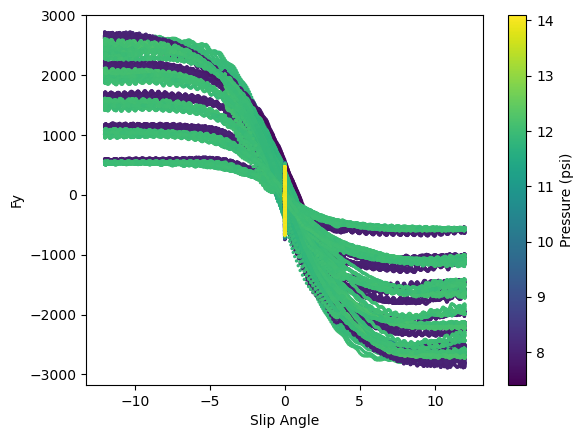

In [14]:
plt.scatter(
    df_clean["SA"],
    df_clean["FY"],
    c=df_clean["P_psi"],
    s=2,
    cmap="viridis"
)

plt.colorbar(label="Pressure (psi)")
plt.xlabel("Slip Angle")
plt.ylabel("Fy")
plt.show()

In [15]:
df_slice = df_clean[
    (df_clean["FZ"] < -600) &
    (df_clean["FZ"] > -750) &
    (abs(df_clean["IA"]) < 0.5)
]
sa_bins = np.linspace(-15, 15, 60)

df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY"].mean().reset_index()
curve_data["SA_center"] = curve_data["SA_bin"].apply(lambda x: x.mid)

/tmp/ipykernel_216/1959083188.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
/tmp/ipykernel_216/1959083188.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY"].mean().reset_index()


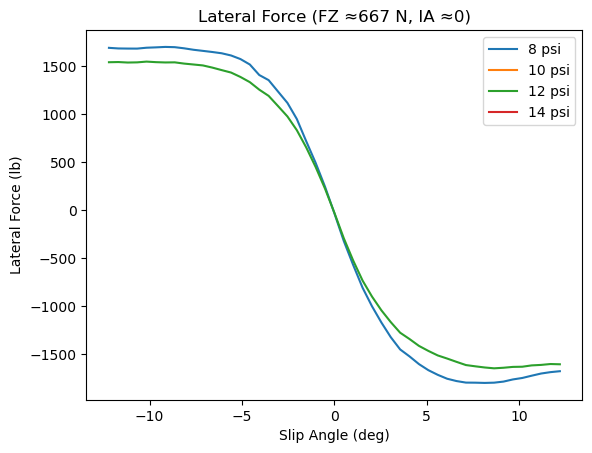

In [16]:
for p in curve_data["P_bin"].unique():
    
    subset = curve_data[curve_data["P_bin"] == p]
    
    plt.plot(
        subset["SA_center"],
        subset["FY"],
        label=p
    )

plt.xlabel("Slip Angle (deg)")
plt.ylabel("Lateral Force (lb)")
plt.title("Lateral Force (FZ ≈667 N, IA ≈0)")
plt.legend()
plt.show()

/tmp/ipykernel_216/2877263967.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
/tmp/ipykernel_216/2877263967.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY"].mean().reset_index()


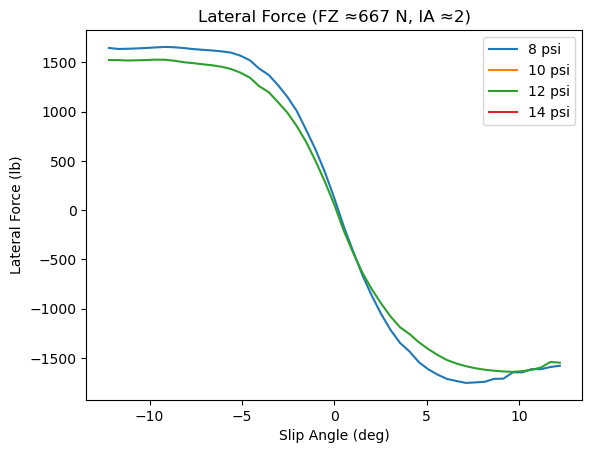

In [17]:
# IA of ~2
df_slice = df_clean[
    (df_clean["FZ"] < -600) &
    (df_clean["FZ"] > -750) &
    (abs(df_clean["IA"]) < 2.5) &
    (abs(df_clean["IA"]) > 1.5)
]
sa_bins = np.linspace(-15, 15, 60)

df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY"].mean().reset_index()
curve_data["SA_center"] = curve_data["SA_bin"].apply(lambda x: x.mid)

for p in curve_data["P_bin"].unique():
    
    subset = curve_data[curve_data["P_bin"] == p]
    
    plt.plot(
        subset["SA_center"],
        subset["FY"],
        label=p
    )

plt.xlabel("Slip Angle (deg)")
plt.ylabel("Lateral Force (lb)")
plt.title("Lateral Force (FZ ≈667 N, IA ≈2)")
plt.legend()
plt.show()

/tmp/ipykernel_216/813084085.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
/tmp/ipykernel_216/813084085.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY"].mean().reset_index()


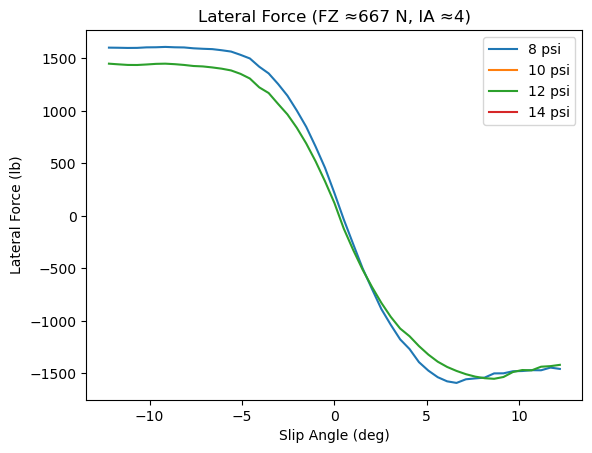

In [18]:
# IA of ~4
df_slice = df_clean[
    (df_clean["FZ"] < -600) &
    (df_clean["FZ"] > -750) &
    (abs(df_clean["IA"]) > 3.5)
]
sa_bins = np.linspace(-15, 15, 60)

df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY"].mean().reset_index()
curve_data["SA_center"] = curve_data["SA_bin"].apply(lambda x: x.mid)

for p in curve_data["P_bin"].unique():
    
    subset = curve_data[curve_data["P_bin"] == p]
    
    plt.plot(
        subset["SA_center"],
        subset["FY"],
        label=p
    )

plt.xlabel("Slip Angle (deg)")
plt.ylabel("Lateral Force (lb)")
plt.title("Lateral Force (FZ ≈667 N, IA ≈4)")
plt.legend()
plt.show()

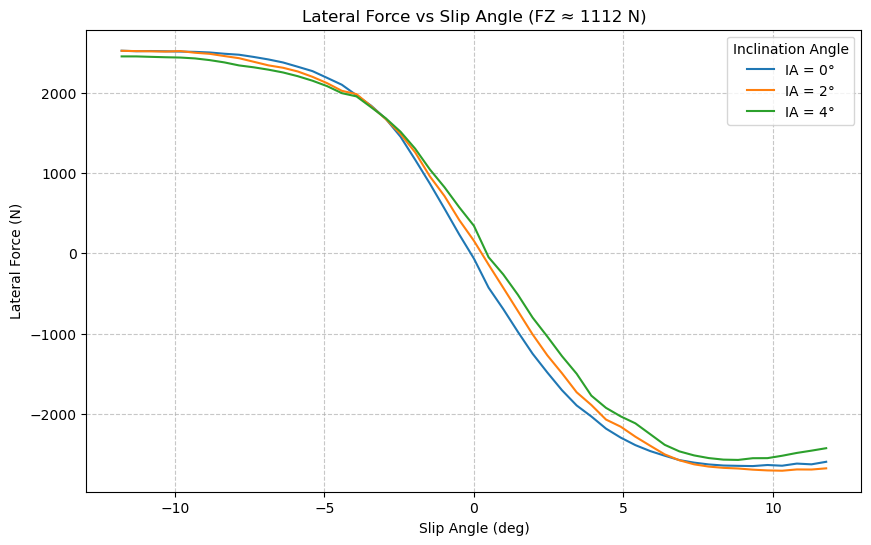

In [19]:
newToleranceFZ = 150 

# Filter FZ
df_filter = df[df['FZ'].between(targetFZ - toleranceFZ, targetFZ + toleranceFZ)].copy()

# Binning the Inclination Angle (IA)
df_filter['IA_round'] = df_filter['IA'].round(0).astype(int)

# Binning Slip Angle (SA) for smooth curves
sa_bins = np.linspace(df_filter['SA'].min(), df_filter['SA'].max(), 50)
df_filter['SA_bin'] = pd.cut(df_filter['SA'], bins=sa_bins)

# Calculate the mean for each group
plot_data = df_filter.groupby(['IA_round', 'SA_bin'], observed=True)['FY'].mean().reset_index()

# Convert bins back to center values for plotting
plot_data['SA_center'] = plot_data['SA_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))
# Plot IA groups that have a significant amount of data
valid_ia = plot_data['IA_round'].unique()

for ia in sorted(valid_ia):
    subset = plot_data[plot_data['IA_round'] == ia]
    if len(subset) > 5: # Filter out groups with too few points
        plt.plot(subset['SA_center'], subset['FY'], label=f'IA = {ia}°')

plt.title(f'Lateral Force vs Slip Angle (FZ ≈ {abs(targetFZ)} N)')
plt.xlabel('Slip Angle (deg)')
plt.ylabel('Lateral Force (N)')
plt.legend(title="Inclination Angle")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

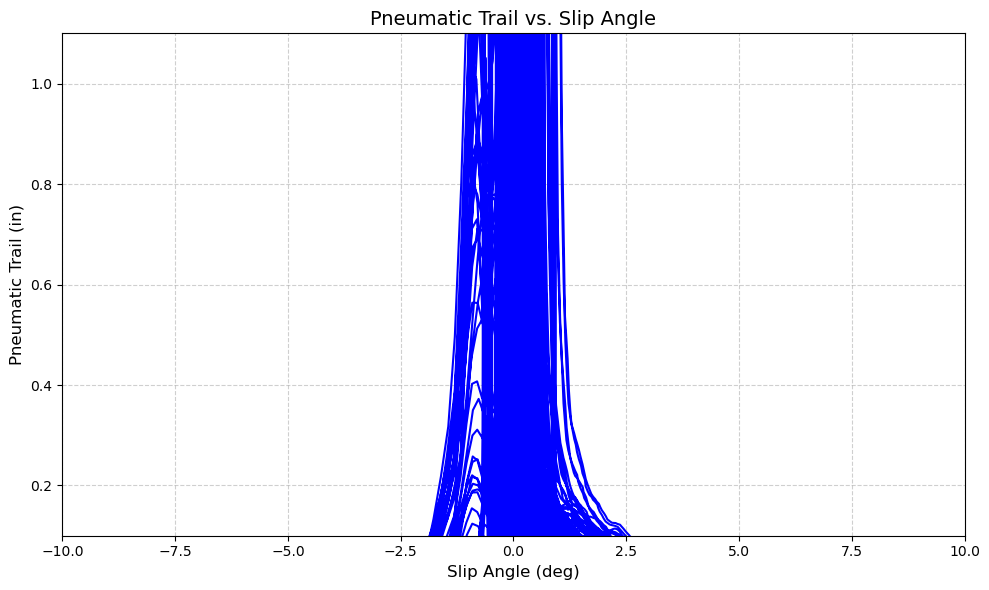

In [20]:
df['trail'] = -df['MZ'] / df['FY']
df['trail'] = df['trail'].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['trail'])

# 3. Plotting
plt.figure(figsize=(10, 6))

# Usually, pneumatic trail is plotted against Slip Angle
plt.plot(df['SA'], df['trail'], color='blue', label='Pneumatic Trail')

plt.title('Pneumatic Trail vs. Slip Angle', fontsize=14)
plt.xlabel('Slip Angle (deg)', fontsize=12)
plt.ylabel('Pneumatic Trail (in)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0.1, 1.1) # Adjust limits based on your tire size
plt.xlim(-10, 10)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()

plt.show()

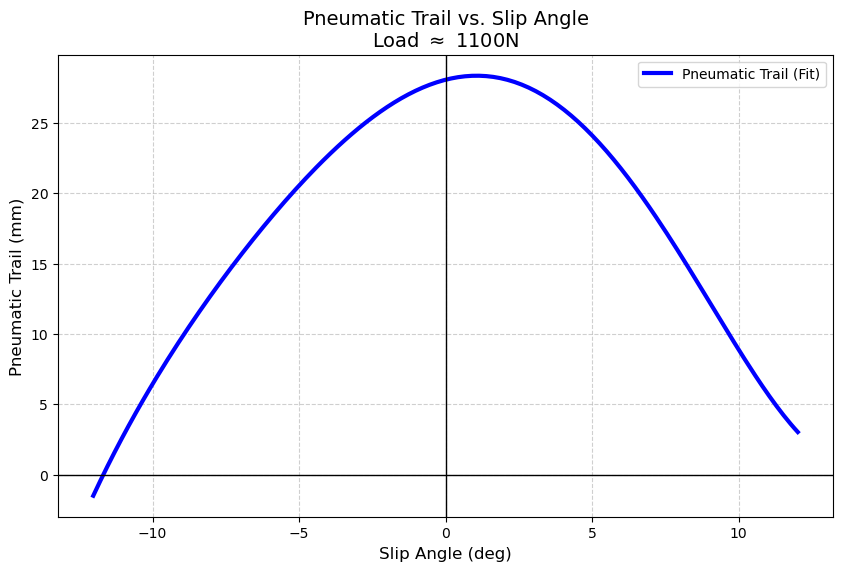

In [21]:
target_fz = -1100 
df_subset = df[(df['FZ'] < target_fz + 50) & (df['FZ'] > target_fz - 50)].copy()

# Calculate Pneumatic Trail (t = -MZ / FY)
# Convert to mm (meters * 1000) for a standard scale
df_subset['trail'] = (-df_subset['MZ'] / df_subset['FY']) * 1000

# Data Cleaning
# Near 0 deg slip, FY is zero. Dividing by zero creates massive "spikes."
# Remove points where Lateral Force (FY) is too small to be reliable.
df_clean = df_subset[df_subset['FY'].abs() > 100].copy()

# Remove extreme outliers
df_clean = df_clean[df_clean['trail'].abs() < 60] 

# Create a Smooth Best-Fit Line
# Uses polynomial fit to make a clean line 
z = np.polyfit(df_clean['SA'], df_clean['trail'], 5)
p = np.poly1d(z)
sa_range = np.linspace(df_clean['SA'].min(), df_clean['SA'].max(), 200)
trail_fit = p(sa_range)

# Plotting
plt.figure(figsize=(10, 6))

# Plot the raw points in light gray to show the data background
#plt.scatter(df_clean['SA'], df_clean['trail'], color='lightgray', s=2, alpha=0.3, label='Raw Data')

# Plot the smooth fitted curve
plt.plot(sa_range, trail_fit, color='blue', linewidth=3, label='Pneumatic Trail (Fit)')

# Formatting
plt.title(f'Pneumatic Trail vs. Slip Angle\nLoad $\\approx$ {abs(target_fz)}N', fontsize=14)
plt.xlabel('Slip Angle (deg)', fontsize=12)
plt.ylabel('Pneumatic Trail (mm)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

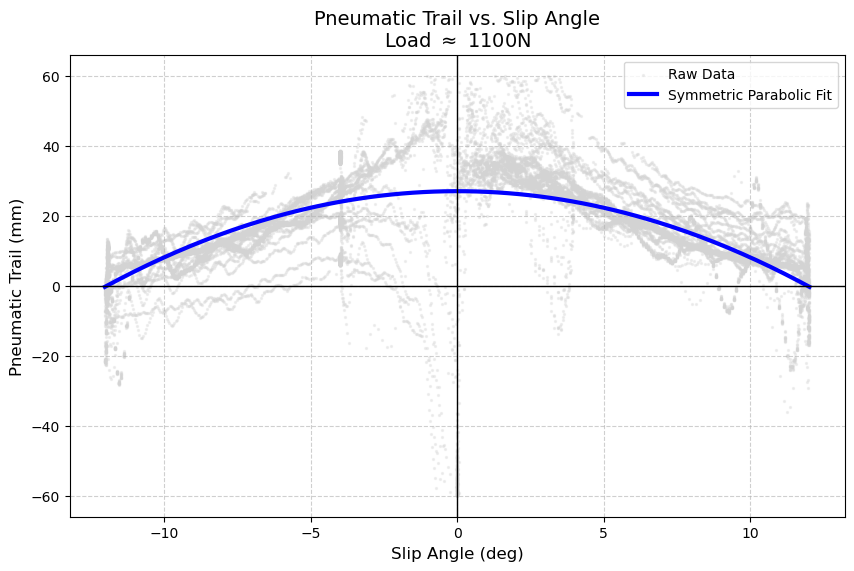

In [22]:
from scipy.optimize import curve_fit
def symmetric_parabola(x, a, c):
    return a*x**2+c

x_data = df_clean['SA'].values
y_data = df_clean['trail'].values

popt, _ = curve_fit(symmetric_parabola, x_data, y_data)
sa_range = np.linspace(x_data.min(), x_data.max(), 200)
trail_fit = symmetric_parabola(sa_range, *popt)

plt.figure(figsize=(10, 6))

# Plot the raw points in light gray to show the data background
plt.scatter(df_clean['SA'], df_clean['trail'], color='lightgray', s=2, alpha=0.3, label='Raw Data')

# Plot the smooth fitted curve
plt.plot(sa_range, trail_fit, color='blue', linewidth=3, label='Symmetric Parabolic Fit')

# Formatting
plt.title(f'Pneumatic Trail vs. Slip Angle\nLoad $\\approx$ {abs(target_fz)}N', fontsize=14)
plt.xlabel('Slip Angle (deg)', fontsize=12)
plt.ylabel('Pneumatic Trail (mm)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [23]:
# Unpack the optimized parameters
a_opt, c_opt = popt

print(f"Optimized a: {a_opt}")
print(f"Optimized c: {c_opt}")

# The resulting equation is:
# trail = a_opt * (slip_angle**2) + c_opt

Optimized a: -0.18897661071681926
Optimized c: 26.978848681055627


--- Optimized Coefficients ---
a_fz:  -0.00011000
a_off: -0.31131010
c_fz:  0.03788164
c_off: 68.93044183

Predicted Trail at 3.0 deg and -4000.0 N: -81.4380 mm


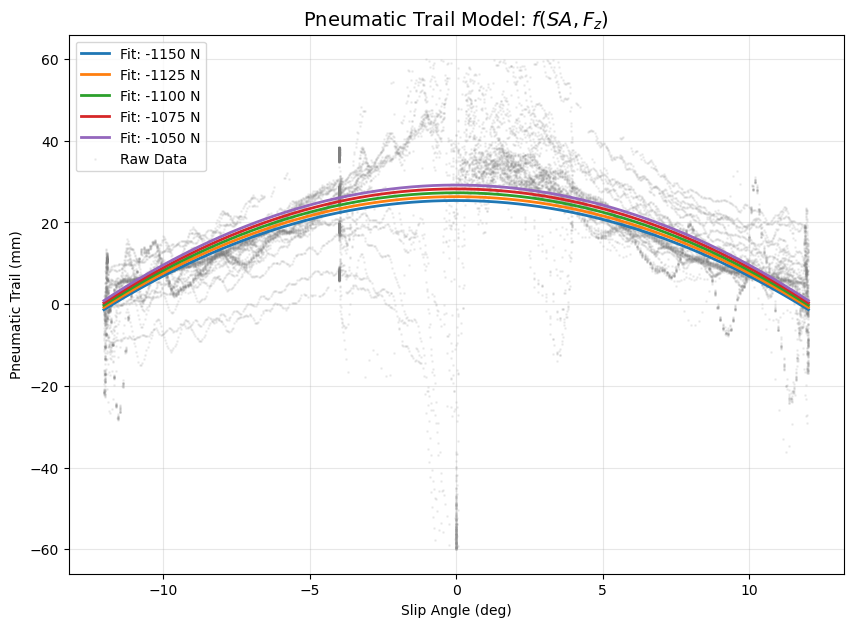

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the 3D Model Function
# Trail = (a_fz * Fz + a_offset) * SA^2 + (c_fz * Fz + c_offset)
def trail_surface_model(coords, a_fz, a_off, c_fz, c_off):
    sa, fz = coords
    a = a_fz * fz + a_off
    c = c_fz * fz + c_off
    return a * sa**2 + c

# 2. Prepare the Data
# Assuming df_clean contains 'SA', 'FZ', and 'trail'
# Ensure Fz is positive for the math to be intuitive, or use absolute values
sa_data = df_clean['SA'].values
fz_data = df_clean['FZ'].values
trail_data = df_clean['trail'].values

# Combine independent variables into a single structure for curve_fit
x_input = (sa_data, fz_data)

# 3. Perform the Fit
# popt contains: [a_fz, a_off, c_fz, c_off]
popt, pcov = curve_fit(trail_surface_model, x_input, trail_data)

# 4. Extract Parameters for Calculation
a_fz, a_off, c_fz, c_off = popt

def get_pneumatic_trail(sa, fz):
    """
    The 'Actual Function' for your calculations.
    Returns trail in mm.
    """
    calc_a = a_fz * fz + a_off
    calc_c = c_fz * fz + c_off
    return calc_a * sa**2 + calc_c

# ---Visualization

print("--- Optimized Coefficients ---")
print(f"a_fz:  {a_fz:.8f}")
print(f"a_off: {a_off:.8f}")
print(f"c_fz:  {c_fz:.8f}")
print(f"c_off: {c_off:.8f}")

'''# Example Calculation:
example_sa = 3.0
example_fz = -4000.0 # Assuming N
predicted = get_pneumatic_trail(example_sa, example_fz)
print(f"\nPredicted Trail at {example_sa} deg and {example_fz} N: {predicted:.4f} mm")'''

# 5. Plotting Multiple Load Slices
plt.figure(figsize=(10, 7))

# Create a range of slip angles for smooth plotting
sa_plot = np.linspace(sa_data.min(), sa_data.max(), 200)

# Pick a few representative loads to visualize the fit
unique_loads = np.sort(df_clean['FZ'].unique())
sample_loads = np.linspace(unique_loads.min(), unique_loads.max(), 5)

for load in sample_loads:
    trail_plot = get_pneumatic_trail(sa_plot, load)
    plt.plot(sa_plot, trail_plot, label=f'Fit: {load:.0f} N', linewidth=2)

plt.scatter(sa_data, trail_data, color='gray', s=1, alpha=0.1, label='Raw Data')
plt.title('Pneumatic Trail Model: $f(SA, F_z)$', fontsize=14)
plt.xlabel('Slip Angle (deg)')
plt.ylabel('Pneumatic Trail (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()